# LEVEL 2

## TASK 3 – Fraud Detection

### Objective

Build a machine learning pipeline to detect fraudulent financial transactions from a highly imbalanced dataset, addressing class imbalance as a core challenge.

### Tech Stack

- Python
- pandas
- scikit-learn
- imbalanced-learn (SMOTE)
- Matplotlib
- Jupyter Notebook

### Project Overview

In this project, we will analyze a highly imbalanced financial transaction dataset, explore fraudulent and non-fraudulent transactions, handle class imbalance, train Logistic Regression and Random Forest models, evaluate their performance using Precision, Recall, F1-Score and AUC-ROC, analyze important features, and discuss the scalability of the fraud detection system.


In [1]:
import pandas as pd
df = pd.read_csv("creditcard.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# Class distribution
class_counts = df["Class"].value_counts()

print("Transaction Counts:")
print(class_counts)

# Calculate percentages
class_percentages = df["Class"].value_counts(normalize=True) * 100

print("\nTransaction Percentages:")
print(class_percentages)

Transaction Counts:
Class
0    284315
1       492
Name: count, dtype: int64

Transaction Percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


### Class Imbalance Analysis

The dataset contains 284,807 transactions, of which 284,315 (99.83%) are non-fraudulent and 492 (0.17%) are fraudulent. This indicates a highly imbalanced dataset, where fraudulent transactions represent only a very small proportion of all transactions.

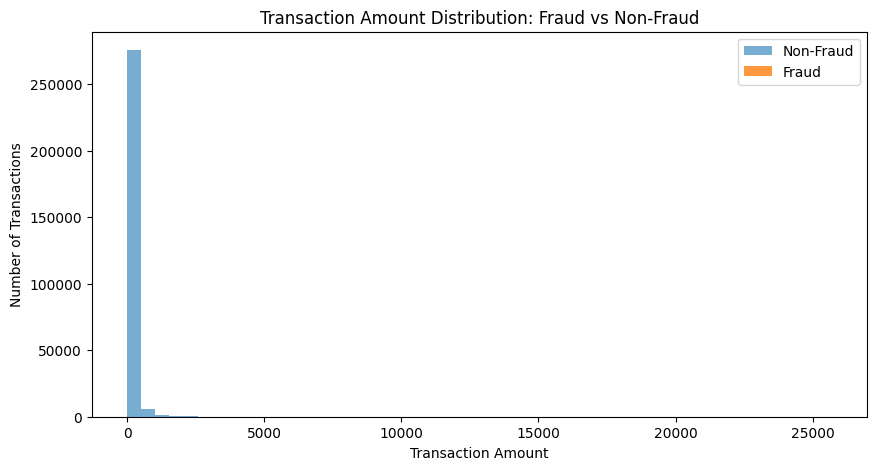

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df[df["Class"] == 0]["Amount"], bins=50, alpha=0.6, label="Non-Fraud")
plt.hist(df[df["Class"] == 1]["Amount"], bins=50, alpha=0.8, label="Fraud")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.legend()
plt.show()

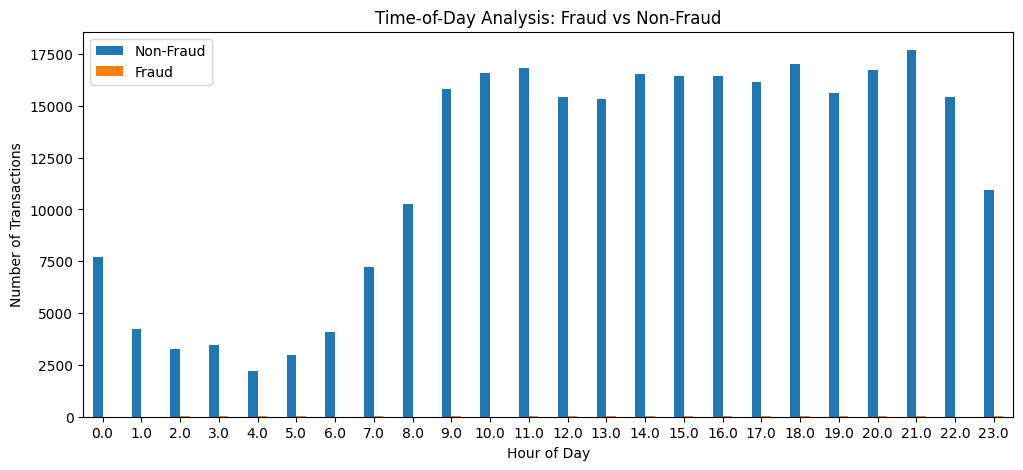

In [4]:
df["Hour"] = (df["Time"] // 3600) % 24

# Count transactions by hour and class
hourly_transactions = df.groupby(["Hour", "Class"]).size().unstack(fill_value=0)

# Plot time-of-day distribution
hourly_transactions.plot(kind="bar", figsize=(12, 5))

plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.title("Time-of-Day Analysis: Fraud vs Non-Fraud")
plt.xticks(rotation=0)
plt.legend(["Non-Fraud", "Fraud"])
plt.show()

### Why Accuracy Is Misleading in Fraud Detection

Accuracy can be misleading when the dataset is highly imbalanced. In this dataset, only 0.17% of transactions are fraudulent, while 99.83% are non-fraudulent.

A model that predicts almost every transaction as non-fraudulent could achieve very high accuracy while failing to detect most fraudulent transactions. Therefore, accuracy alone is not a reliable metric for fraud detection.

Metrics such as **Precision, Recall, F1-Score, and AUC-ROC** provide a better evaluation of model performance. In particular, Recall is important because it measures how many actual fraudulent transactions are correctly identified.


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Class"])
y = df["Class"]

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set class distribution:")
print(y_train.value_counts())

print("\nTesting set class distribution:")
print(y_test.value_counts())

Training set class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing set class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

random_forest_model = RandomForestClassifier(
    class_weight="balanced",
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Class imbalance handling: class_weight='balanced'")

Class imbalance handling: class_weight='balanced'


In [7]:
from sklearn.preprocessing import StandardScaler

# Scale features for Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model.fit(X_train_scaled, y_train)

random_forest_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")
print("Random Forest model trained successfully.")

Logistic Regression model trained successfully.
Random Forest model trained successfully.


In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

y_pred_logistic = logistic_model.predict(X_test_scaled)
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Logistic Regression metrics
print("Logistic Regression")
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1-Score:", f1_score(y_test, y_pred_logistic))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_logistic))

print("\nRandom Forest")
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_rf))

Logistic Regression
Precision: 0.0559748427672956
Recall: 0.9081632653061225
F1-Score: 0.10545023696682465
AUC-ROC: 0.9737784674927934

Random Forest
Precision: 0.961038961038961
Recall: 0.7551020408163265
F1-Score: 0.8457142857142858
AUC-ROC: 0.957984518019363


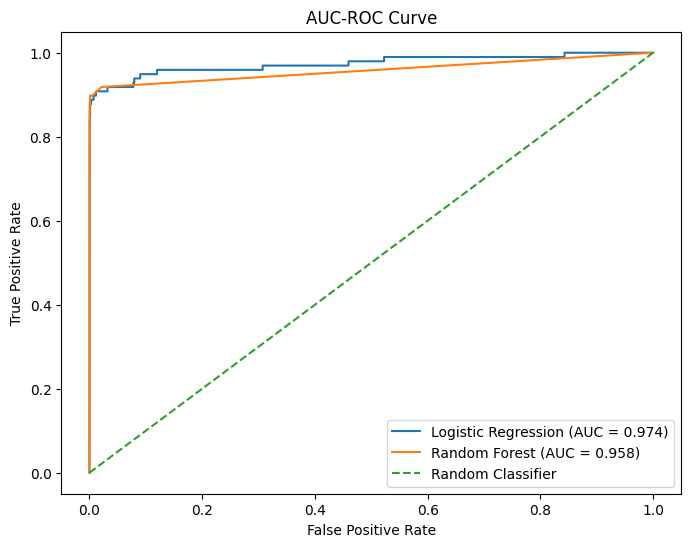

In [9]:
from sklearn.metrics import roc_curve

# Calculate ROC curves
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_logistic):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve")
plt.legend()
plt.show()

### Recall vs. Precision Trade-off

For fraud detection, **Recall is particularly important** because it measures the percentage of actual fraudulent transactions that are correctly identified. A low Recall means that many fraudulent transactions are missed.

However, Precision is also important because it measures how many transactions predicted as fraudulent are actually fraudulent. Low Precision can result in many legitimate transactions being incorrectly flagged as fraud.

In this project, Logistic Regression achieved a higher Recall of **90.82%**, meaning it detected more fraudulent transactions, but its Precision was only **5.60%**. Random Forest achieved a much higher Precision of **96.10%** with a Recall of **75.51%**.

Therefore, fraud detection requires a balance between Recall and Precision. The appropriate balance depends on the business cost of missed fraud versus false alerts.

In [10]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
   Feature  Importance
14     V14    0.202305
10     V10    0.143561
12     V12    0.099744
4       V4    0.085452
11     V11    0.074949
17     V17    0.065974
3       V3    0.048235
7       V7    0.031665
16     V16    0.029495
2       V2    0.025011


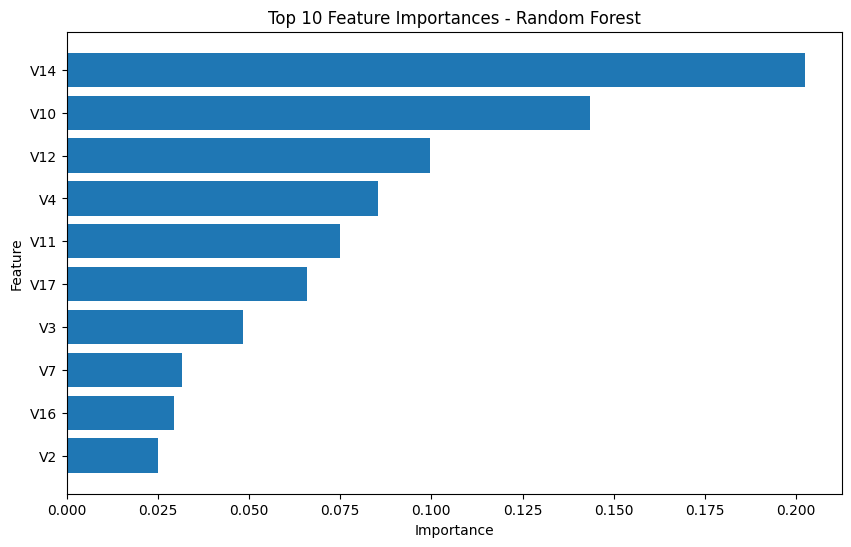

In [11]:
# Plot top 10 feature importances
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")
plt.gca().invert_yaxis()
plt.show()

### Scalability

To handle 1 million transactions per hour, the fraud detection system should use an efficient and scalable prediction pipeline. The trained model can be deployed as a real-time API service that processes transactions in batches or streams.

A scalable architecture could use distributed processing and message queues to handle high transaction volumes. Multiple instances of the prediction service can run in parallel to distribute the workload. The model should also be monitored regularly for changes in fraud patterns and retrained when necessary.

Random Forest and Logistic Regression can provide fast predictions after training, making them suitable for high-volume transaction scoring when deployed with appropriate infrastructure.

### Conclusion

The fraud detection model successfully identified fraudulent and non-fraudulent transactions from a highly imbalanced dataset. Class imbalance was handled using `class_weight='balanced'`, and Logistic Regression and Random Forest models were trained and evaluated.

Random Forest achieved a strong balance between Precision and Recall, while Logistic Regression achieved higher Recall and AUC-ROC. The analysis also identified the most important features contributing to fraud classification. Overall, the project demonstrates the importance of using appropriate evaluation metrics and effective class-imbalance handling techniques for fraud detection.